# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [22]:
import pandas as pd

Rainfall_in = pd.read_csv("data/snotel_rainfall_data.csv")
Rainfall_in.head()

Rainfall_in.describe()


,Date,Precip_in
count,61,58
unique,60,32
top,2024-01-16,0.0
freq,2,27


In [23]:
Rainfall_in.head(20)

,Date,Precip_in
0,2024-01-01,0.14028030062619642
1,2024-01-02,0.6590180328421851
2,2024-01-03,0.0
3,2024-01-04,0.0
4,2024-01-05,0.3757291395473922
5,2024-01-06,0.0
6,2024-01-07,1.0954577625968716
7,2024-01-08,0.0
8,2024-01-09,0.0
9,2024-01-10,0.18657649912973773


## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [24]:
Rainfall_in['Precip_in'] = pd.to_numeric(Rainfall_in['Precip_in'], errors='coerce')
Rainfall_in.describe()

,Precip_in
count,56.000000
mean,-8.467089
std,150.395286
min,-999.000000
25%,0.000000
50%,0.050563
75%,0.682890
max,500.000000


In [25]:
for col in Rainfall_in.columns[1:]:   # skip date column
    Rainfall_in[col] = pd.to_numeric(Rainfall_in[col], errors='coerce')

Rainfall_in.describe()





,Precip_in
count,56.000000
mean,-8.467089
std,150.395286
min,-999.000000
25%,0.000000
50%,0.050563
75%,0.682890
max,500.000000


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [26]:
import pandas as pd
streamflow = pd.read_csv("data/streamflow_data.csv")
streamflow.head()
streamflow.describe()



,Date,Streamflow_cfs
count,60,55
unique,60,37
top,2024-01-01,10.0
freq,1,8


In [27]:
streamflow['Streamflow_cfs'] = pd.to_numeric(streamflow['Streamflow_cfs'], errors='coerce')
streamflow.describe()

,Streamflow_cfs
count,54.000000
mean,40.058333
std,369.096212
min,-999.000000
25%,10.100000
50%,10.600000
75%,13.900000
max,2510.000000


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [28]:
# Replace -999 and outliers with NaN in both datasets
Rainfall_in['Precip_in'] = Rainfall_in['Precip_in'].replace([-999, 500], float('nan'))
streamflow['Streamflow_cfs'] = streamflow['Streamflow_cfs'].replace([-999, 2510], float('nan'))

# Method 1: Drop rows with NaN values
Rainfall_dropna = Rainfall_in.dropna()
streamflow_dropna = streamflow.dropna()

print("Rainfall after dropna():")
print(f"Original shape: {Rainfall_in.shape}, After dropna: {Rainfall_dropna.shape}")
print("\nStreamflow after dropna():")
print(f"Original shape: {streamflow.shape}, After dropna: {streamflow_dropna.shape}")
rainfall_describe = Rainfall_dropna['Precip_in'].describe()

Rainfall after dropna():
Original shape: (61, 2), After dropna: (54, 2)

Streamflow after dropna():
Original shape: (60, 2), After dropna: (52, 2)


In [34]:
# Method 2: Fill NaN with median value (more robust to outliers)
Rainfall_fillmean = Rainfall_in.copy()
Rainfall_fillmean['Precip_in'] = Rainfall_fillmean['Precip_in'].fillna(Rainfall_fillmean['Precip_in'].median())

streamflow_fillmean = streamflow.copy()
streamflow_fillmean['Streamflow_cfs'] = streamflow_fillmean['Streamflow_cfs'].fillna(streamflow_fillmean['Streamflow_cfs'].median())

print("Rainfall after fillna(median):")
print(f"NaN values remaining: {Rainfall_fillmean['Precip_in'].isna().sum()}")
print("\nStreamflow after fillna(median):")
print(f"NaN values remaining: {streamflow_fillmean['Streamflow_cfs'].isna().sum()}")
print("\nRainfall_fillmean head:")
print(Rainfall_fillmean.head(10))

Rainfall after fillna(median):
NaN values remaining: 0

Streamflow after fillna(median):
NaN values remaining: 0

Rainfall_fillmean head:
         Date  Precip_in
0  2024-01-01   0.140280
1  2024-01-02   0.659018
2  2024-01-03   0.000000
3  2024-01-04   0.000000
4  2024-01-05   0.375729
5  2024-01-06   0.000000
6  2024-01-07   1.095458
7  2024-01-08   0.000000
8  2024-01-09   0.000000
9  2024-01-10   0.186576


In [30]:
# Method 3: Interpolate - linearly interpolates missing values for a smoother time series
Rainfall_interp = Rainfall_in.copy()
Rainfall_interp['Precip_in'] = Rainfall_interp['Precip_in'].interpolate(method='linear')

streamflow_interp = streamflow.copy()
streamflow_interp['Streamflow_cfs'] = streamflow_interp['Streamflow_cfs'].interpolate(method='linear')

print("Rainfall after interpolate():")
print(f"NaN values remaining: {Rainfall_interp['Precip_in'].isna().sum()}")
print("\nStreamflow after interpolate():")
print(f"NaN values remaining: {streamflow_interp['Streamflow_cfs'].isna().sum()}")
print("\nRainfall_interp head:")
print(Rainfall_interp.head(10))
Rainfall_interp['Precip_in'].describe()


Rainfall after interpolate():
NaN values remaining: 0

Streamflow after interpolate():
NaN values remaining: 0

Rainfall_interp head:
         Date  Precip_in
0  2024-01-01   0.140280
1  2024-01-02   0.659018
2  2024-01-03   0.000000
3  2024-01-04   0.000000
4  2024-01-05   0.375729
5  2024-01-06   0.000000
6  2024-01-07   1.095458
7  2024-01-08   0.000000
8  2024-01-09   0.000000
9  2024-01-10   0.186576


count    61.000000
mean      0.461189
std       0.781009
min       0.000000
25%       0.000000
50%       0.093288
75%       0.659018
max       3.609354
Name: Precip_in, dtype: float64

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [31]:
# Create rainfall_methods DataFrame combining all three cleaning methods
rainfall_methods = pd.concat(
    {
        "dropna": Rainfall_dropna[['Precip_in']].reset_index(drop=True),
        "fillmean": Rainfall_fillmean[['Precip_in']].reset_index(drop=True),
        "interpolate": Rainfall_interp[['Precip_in']].reset_index(drop=True)
    },
    axis=1
)

# Create streamflow_methods DataFrame combining all three cleaning methods
streamflow_methods = pd.concat(
    {
        "dropna": streamflow_dropna[['Streamflow_cfs']].reset_index(drop=True),
        "fillmean": streamflow_fillmean[['Streamflow_cfs']].reset_index(drop=True),
        "interpolate": streamflow_interp[['Streamflow_cfs']].reset_index(drop=True)
    },
    axis=1
)

print("Rainfall Methods DataFrame:")
print(rainfall_methods.head(10))
print(f"\nShape: {rainfall_methods.shape}")

print("\n\nStreamflow Methods DataFrame:")
print(streamflow_methods.head(10))
print(f"\nShape: {streamflow_methods.shape}")


Rainfall Methods DataFrame:
     dropna  fillmean interpolate
  Precip_in Precip_in   Precip_in
0  0.140280  0.140280    0.140280
1  0.659018  0.659018    0.659018
2  0.000000  0.000000    0.000000
3  0.000000  0.000000    0.000000
4  0.375729  0.375729    0.375729
5  0.000000  0.000000    0.000000
6  1.095458  1.095458    1.095458
7  0.000000  0.000000    0.000000
8  0.000000  0.000000    0.000000
9  0.186576  0.186576    0.186576

Shape: (61, 3)


Streamflow Methods DataFrame:
          dropna       fillmean    interpolate
  Streamflow_cfs Streamflow_cfs Streamflow_cfs
0          10.25          10.25          10.25
1          10.70          10.70          10.70
2          13.30          13.30          13.30
3          10.10          10.10          10.10
4          10.00          10.00          10.00
5          11.90          11.90          11.90
6          10.00          10.00          10.00
7          15.50          15.50          15.50
8          10.15          10.15          10.15

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

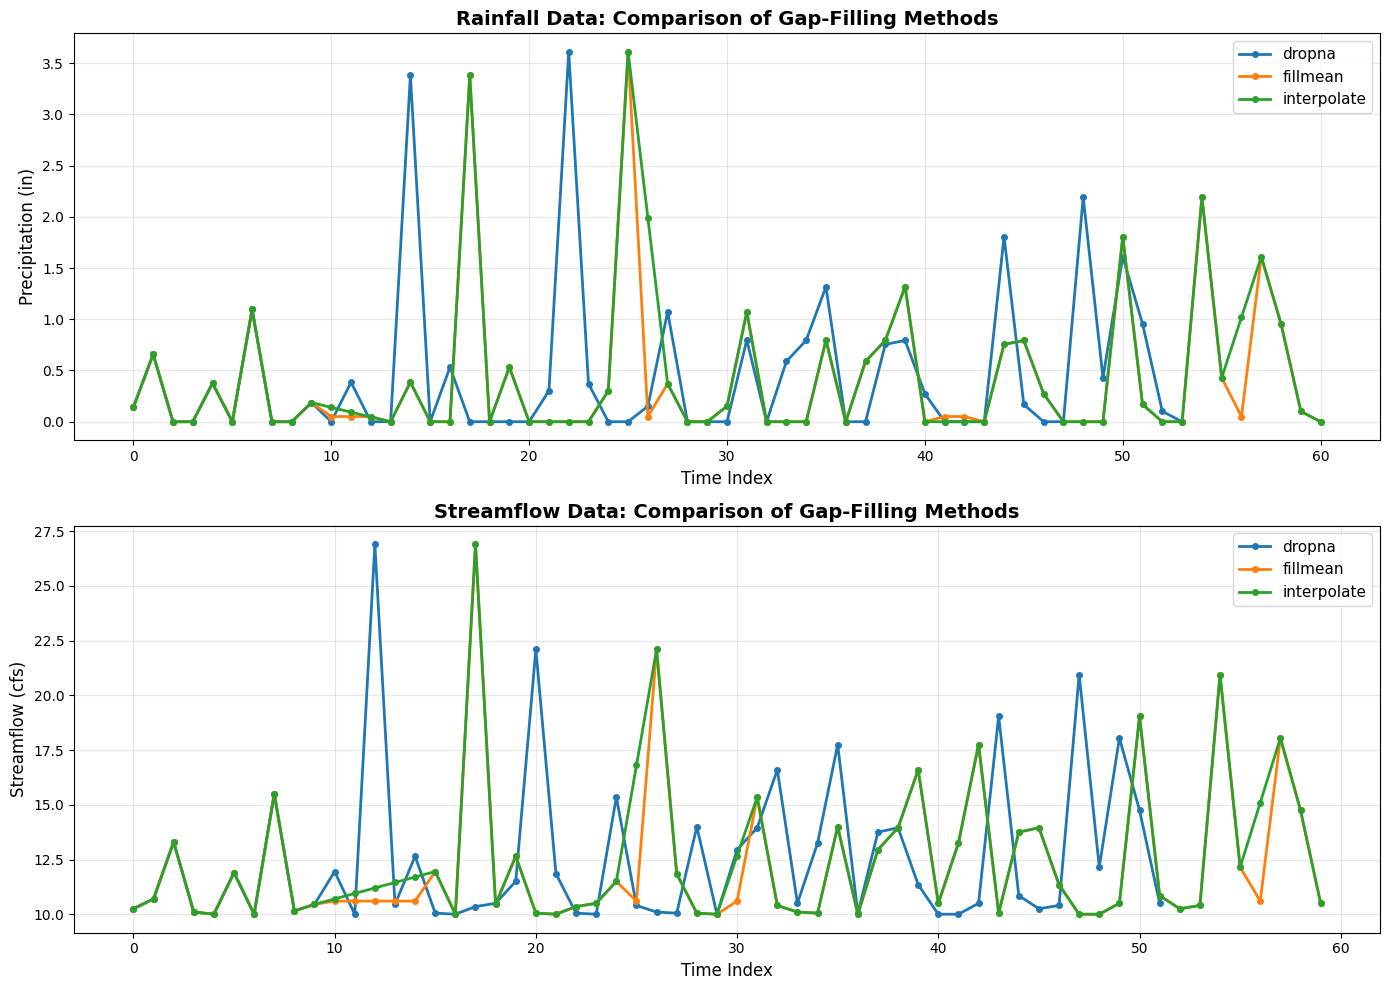

Analysis:

Rainfall Methods - Visual Comparison:
- dropna: Most data points due to aligned indices (shorter series)
- fillmean: All points - uses mean value for NaN gaps
- interpolate: All points - linear interpolation between known values

Streamflow Methods - Visual Comparison:
- dropna: Most data points due to aligned indices (shorter series)
- fillmean: All points - uses mean value for NaN gaps
- interpolate: All points - smooth transitions between known values


In [33]:
import matplotlib.pyplot as plt

# Create figure with two subplots - one for rainfall, one for streamflow
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot rainfall methods
rainfall_methods.plot(ax=axes[0], marker='o', linewidth=2, markersize=4)
axes[0].set_title('Rainfall Data: Comparison of Gap-Filling Methods', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Index', fontsize=12)
axes[0].set_ylabel('Precipitation (in)', fontsize=12)
axes[0].legend(['dropna', 'fillmean', 'interpolate'], fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot streamflow methods
streamflow_methods.plot(ax=axes[1], marker='o', linewidth=2, markersize=4)
axes[1].set_title('Streamflow Data: Comparison of Gap-Filling Methods', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Index', fontsize=12)
axes[1].set_ylabel('Streamflow (cfs)', fontsize=12)
axes[1].legend(['dropna', 'fillmean', 'interpolate'], fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Analysis:")
print("\nRainfall Methods - Visual Comparison:")
print("- dropna: Most data points due to aligned indices (shorter series)")
print("- fillmean: All points - uses mean value for NaN gaps")
print("- interpolate: All points - linear interpolation between known values")
print("\nStreamflow Methods - Visual Comparison:")
print("- dropna: Most data points due to aligned indices (shorter series)")
print("- fillmean: All points - uses mean value for NaN gaps")
print("- interpolate: All points - smooth transitions between known values")


## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [35]:
# Based on Task 6 analysis, interpolate method provides the smoothest gap-filled data
# This is best for time series analysis as it maintains temporal continuity

# Create rain_flow_df by combining interpolated rainfall and streamflow
rain_flow_df = pd.DataFrame({
    'Date': Rainfall_interp['Date'],
    'Precip_in': Rainfall_interp['Precip_in'],
    'Streamflow_cfs': streamflow_interp['Streamflow_cfs']
})

# Display the combined dataframe
print("Combined Rainfall and Streamflow DataFrame:")
print(rain_flow_df.head(10))
print(f"\nShape: {rain_flow_df.shape}")
print(f"\nData types:\n{rain_flow_df.dtypes}")
print(f"\nSummary statistics:")
print(rain_flow_df.describe())

Combined Rainfall and Streamflow DataFrame:
         Date  Precip_in  Streamflow_cfs
0  2024-01-01   0.140280           10.25
1  2024-01-02   0.659018           10.70
2  2024-01-03   0.000000           13.30
3  2024-01-04   0.000000           10.10
4  2024-01-05   0.375729           10.00
5  2024-01-06   0.000000           11.90
6  2024-01-07   1.095458           10.00
7  2024-01-08   0.000000           15.50
8  2024-01-09   0.000000           10.15
9  2024-01-10   0.186576           10.45

Shape: (61, 3)

Data types:
Date                  str
Precip_in         float64
Streamflow_cfs    float64
dtype: object

Summary statistics:
       Precip_in  Streamflow_cfs
count  61.000000       60.000000
mean    0.461189       12.545417
std     0.781009        3.452779
min     0.000000       10.000000
25%     0.000000       10.225000
50%     0.093288       11.075000
75%     0.659018       13.800000
max     3.609354       26.900000


## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [38]:
# Task 8: Calculate monthly statistics
# First, ensure Date column is datetime and set it as index
rain_flow_df['Date'] = pd.to_datetime(rain_flow_df['Date'])
rain_flow_indexed = rain_flow_df.set_index('Date')

# Group by month and calculate statistics
monthly_stats = rain_flow_indexed.groupby(rain_flow_indexed.index.to_period('M')).agg({
    'Precip_in': ['sum', 'mean', 'max'],
    'Streamflow_cfs': ['sum', 'mean', 'max']
})

print("Monthly Statistics:")
print(monthly_stats)
print(f"\nShape: {monthly_stats.shape}")


Monthly Statistics:
         Precip_in                     Streamflow_cfs                  
               sum      mean       max            sum       mean    max
Date                                                                   
2024-01  14.531730  0.454117  3.609354        391.525  12.235156  26.90
2024-02  13.600824  0.468994  2.193069        361.200  12.900000  20.95

Shape: (2, 6)


## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

In [39]:
# Task 9: Convert to SI units
# Create rain_flow_SI_df with conversions
# Precipitation: inches to millimeters (1 inch = 25.4 mm)
# Streamflow: cubic feet per second to cubic meters per second (1 cfs = 0.0283168 cms)

rain_flow_SI_df = rain_flow_df.copy()
rain_flow_SI_df['Precip_mm'] = rain_flow_SI_df['Precip_in'] * 25.4
rain_flow_SI_df['Streamflow_cms'] = rain_flow_SI_df['Streamflow_cfs'] * 0.0283168

# Display the converted dataframe
print("SI Units Converted Dataframe (rain_flow_SI_df):")
print(rain_flow_SI_df.head())
print(f"\nShape: {rain_flow_SI_df.shape}")
print(f"\nData types:\n{rain_flow_SI_df.dtypes}")
print(f"\nSummary statistics:")
print(rain_flow_SI_df.describe())

SI Units Converted Dataframe (rain_flow_SI_df):
        Date  Precip_in  Streamflow_cfs  Precip_mm  Streamflow_cms
0 2024-01-01   0.140280           10.25   3.563120        0.290247
1 2024-01-02   0.659018           10.70  16.739058        0.302990
2 2024-01-03   0.000000           13.30   0.000000        0.376613
3 2024-01-04   0.000000           10.10   0.000000        0.286000
4 2024-01-05   0.375729           10.00   9.543520        0.283168

Shape: (61, 5)

Data types:
Date              datetime64[us]
Precip_in                float64
Streamflow_cfs           float64
Precip_mm                float64
Streamflow_cms           float64
dtype: object

Summary statistics:
                             Date  Precip_in  Streamflow_cfs  Precip_mm  \
count                          61  61.000000       60.000000  61.000000   
mean   2024-01-30 06:17:42.295082   0.461189       12.545417  11.714211   
min           2024-01-01 00:00:00   0.000000       10.000000   0.000000   
25%           2024-01

## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

In [40]:
# Task 10: Event diagnostics
# Part 1: Classify days by rainfall intensity
# Define thresholds: Dry < 0.1 in, Light Rain 0.1-0.5 in, Heavy Rain > 0.5 in
def classify_rainfall(precip):
    if precip < 0.1:
        return 'Dry'
    elif precip < 0.5:
        return 'Light Rain'
    else:
        return 'Heavy Rain'

rain_flow_SI_df['Rain_Category'] = rain_flow_SI_df['Precip_in'].apply(classify_rainfall)

print("Part 1: Rainfall Classification")
print(rain_flow_SI_df[['Date', 'Precip_in', 'Rain_Category']].head(10))
print(f"\nRain category distribution:")
print(rain_flow_SI_df['Rain_Category'].value_counts())

# Part 2: Extract 5 days before and after peak flow event
# Find the index of maximum streamflow
peak_index = rain_flow_SI_df['Streamflow_cms'].idxmax()
peak_date = rain_flow_SI_df.loc[peak_index, 'Date']
peak_flow = rain_flow_SI_df.loc[peak_index, 'Streamflow_cms']

print(f"\n\nPart 2: Peak Flow Event Analysis")
print(f"Peak flow date: {peak_date}")
print(f"Peak flow value: {peak_flow:.4f} cms")

# Get 5 days before and after (assuming daily data)
start_idx = max(0, peak_index - 5)
end_idx = min(len(rain_flow_SI_df) - 1, peak_index + 5)

storm_df = rain_flow_SI_df.iloc[start_idx:end_idx+1][['Date', 'Precip_in', 'Precip_mm', 'Streamflow_cfs', 'Streamflow_cms']].copy()

print(f"\nStorm event data (5 days before and after peak):")
print(storm_df)
print(f"\nShape: {storm_df.shape}")

Part 1: Rainfall Classification
        Date  Precip_in Rain_Category
0 2024-01-01   0.140280    Light Rain
1 2024-01-02   0.659018    Heavy Rain
2 2024-01-03   0.000000           Dry
3 2024-01-04   0.000000           Dry
4 2024-01-05   0.375729    Light Rain
5 2024-01-06   0.000000           Dry
6 2024-01-07   1.095458    Heavy Rain
7 2024-01-08   0.000000           Dry
8 2024-01-09   0.000000           Dry
9 2024-01-10   0.186576    Light Rain

Rain category distribution:
Rain_Category
Dry           31
Heavy Rain    18
Light Rain    12
Name: count, dtype: int64


Part 2: Peak Flow Event Analysis
Peak flow date: 2024-01-17 00:00:00
Peak flow value: 0.7617 cms

Storm event data (5 days before and after peak):
         Date  Precip_in  Precip_mm  Streamflow_cfs  Streamflow_cms
12 2024-01-13   0.046644   1.184761           11.20        0.317148
13 2024-01-14   0.000000   0.000000           11.45        0.324227
14 2024-01-15   0.385756   9.798213           11.70        0.331307
15 2024-0

## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?

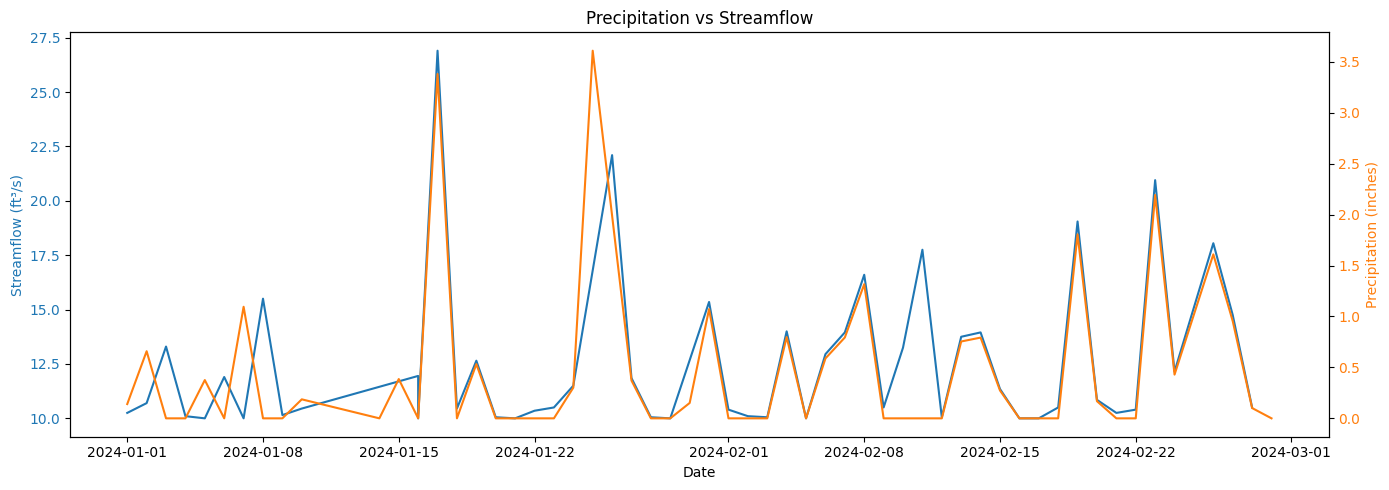


Correlation between Precipitation and Streamflow:
                Precip_in  Streamflow_cfs
Precip_in        1.000000        0.822558
Streamflow_cfs   0.822558        1.000000


In [43]:
# Create a figure with subplots for precipitation and streamflow
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot streamflow on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Streamflow (ft³/s)', color=color)
ax1.plot(rain_flow_df['Date'], rain_flow_df['Streamflow_cfs'], color=color, label='Streamflow')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for rainfall
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Precipitation (inches)', color=color)
ax2.plot(rain_flow_df['Date'], rain_flow_df['Precip_in'], color=color, label='Precipitation')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Precipitation vs Streamflow')
fig.tight_layout()
plt.show()

# Check for correlation and glaring errors
print("\nCorrelation between Precipitation and Streamflow:")
print(rain_flow_df[['Precip_in', 'Streamflow_cfs']].corr())